# ✅ VERSIÓN ACTUALIZADA — 50.000 MUESTRAS + REAL VS PRONOSTICADO

**Cambios de esta versión:**
- `MUESTRA_POR_ORIGEN_H = 50_000`
- comparación detallada **real vs. pronosticado** sobre el test temporal;
- archivo `real_vs_pronosticado_test.parquet`;
- resumen por horizonte;
- análisis por segmento de consumo;
- gráficas real vs. pronosticado.

---

# Modelado global de consumo — predicción a 3 y 6 meses

Este notebook parte del archivo ya preprocesado:

`serie_mensual_modelado_preprocesada.parquet`

No repite la reconstrucción mensual ni el filtro de Alumbrado Público.

## Modelos a comparar

1. **LightGBM**
2. **XGBoost**
3. **CatBoost**

Los tres utilizan exactamente las mismas variables temporales y la misma transformación del target para que la comparación sea justa.

## Estrategia

- Un **modelo global** aprende de todos los clientes; no se crea un modelo por NIU.
- `NIU` no se usa como predictor.
- Los meses faltantes permanecen como `NaN`.
- Los consumos cero reales se conservan.
- Los extremos no se eliminan.
- Se entrena sobre `log1p(consumo)` debido a la fuerte asimetría del consumo.
- Las métricas se calculan de nuevo en kWh reales.
- Se predicen simultáneamente los horizontes `t+1` a `t+6`.
- Se guardan salidas específicas de 3 y 6 meses.

## Split temporal

- **Train de comparación:** targets históricos hasta julio de 2024.
- **Validación 1:** corte julio de 2024 → agosto 2024 a enero 2025.
- **Validación 2:** corte enero de 2025 → febrero a julio de 2025.
- **Test independiente:** corte julio de 2025 → agosto 2025 a enero 2026.
- **Pronóstico final:** se reentrena el modelo ganador con todo lo conocido hasta enero de 2026 y se predice febrero a julio de 2026.

La selección del modelo se realiza **solo con validación**. El test se conserva como comprobación posterior.

## Dependencias

Si los imports de modelos fallan, ejecuta una celda con:

```python
%pip install -U lightgbm xgboost catboost scikit-learn joblib pyarrow
```

Después reinicia el kernel y ejecuta nuevamente el notebook.

In [1]:
# ============================================================
# 1. LIBRERÍAS Y RUTAS
# ============================================================

from pathlib import Path
import gc
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

import joblib

try:
    from lightgbm import LGBMRegressor
except ImportError as e:
    raise ImportError(
        "Falta LightGBM. Ejecuta: %pip install -U lightgbm"
    ) from e

try:
    from xgboost import XGBRegressor
except ImportError as e:
    raise ImportError(
        "Falta XGBoost. Ejecuta: %pip install -U xgboost"
    ) from e

try:
    from catboost import CatBoostRegressor
except ImportError as e:
    raise ImportError(
        "Falta CatBoost. Ejecuta: %pip install -U catboost"
    ) from e

warnings.filterwarnings("ignore")

BASE_DIR = Path(
    r"C:\Users\Home\Documents\Datos Ebsa"
)

PREPROC_DIR = (
    BASE_DIR
    / "Serie_tiempo_consumo"
    / "preprocesamiento_modelo"
)

RUTA_ENTRADA = (
    PREPROC_DIR
    / "serie_mensual_modelado_preprocesada.parquet"
)

MODELO_DIR = (
    BASE_DIR
    / "Serie_tiempo_consumo"
    / "modelacion_consumo"
)

MODELO_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RUTA_METRICAS_VALIDACION = (
    MODELO_DIR / "metricas_validacion_modelos.csv"
)

RUTA_METRICAS_TEST = (
    MODELO_DIR / "metricas_test_modelos.csv"
)

RUTA_COMPARACION = (
    MODELO_DIR / "comparacion_modelos.csv"
)

RUTA_MODELO = (
    MODELO_DIR / "modelo_consumo_ganador.joblib"
)

RUTA_PRED_3M = (
    MODELO_DIR / "predicciones_consumo_3_meses.parquet"
)

RUTA_PRED_6M = (
    MODELO_DIR / "predicciones_consumo_6_meses.parquet"
)


RUTA_REAL_VS_PRED_TEST = (
    MODELO_DIR
    / "real_vs_pronosticado_test.parquet"
)

RUTA_REAL_VS_PRED_RESUMEN = (
    MODELO_DIR
    / "real_vs_pronosticado_test_resumen.csv"
)

RUTA_REAL_VS_PRED_SEGMENTOS = (
    MODELO_DIR
    / "real_vs_pronosticado_test_segmentos.csv"
)

print("Entrada :", RUTA_ENTRADA)
print("Salidas :", MODELO_DIR)

Entrada : C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\preprocesamiento_modelo\serie_mensual_modelado_preprocesada.parquet
Salidas : C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\modelacion_consumo


In [2]:
# ============================================================
# 2. CONFIGURACIÓN
# ============================================================

SEED = 42

HORIZONTES = [1, 2, 3, 4, 5, 6]

# Control de memoria/tiempo.
# 50.000 aprovecha mejor los tiempos observados en la ejecución anterior.
# Si la RAM se vuelve limitante, bajar temporalmente a 30_000.
MUESTRA_POR_ORIGEN_H = 50_000

PRIMER_ORIGEN_TRAIN = pd.Timestamp(
    "2023-01-01"
)

MAX_TARGET_TRAIN_COMPARACION = pd.Timestamp(
    "2024-07-01"
)

CORTES_VALIDACION = [
    pd.Timestamp("2024-07-01"),
    pd.Timestamp("2025-01-01"),
]

CORTE_TEST = pd.Timestamp(
    "2025-07-01"
)

MIN_MESES_VALIDOS_12 = 6

print("Horizontes:", HORIZONTES)
print(
    "Muestra por origen/horizonte:",
    f"{MUESTRA_POR_ORIGEN_H:,}"
)

print("\nCONFIGURACIÓN ACTUALIZADA")
print("-" * 60)
print(f"MUESTRA_POR_ORIGEN_H = {MUESTRA_POR_ORIGEN_H:,}")
print("Real vs pronosticado = ACTIVADO")


Horizontes: [1, 2, 3, 4, 5, 6]
Muestra por origen/horizonte: 50,000

CONFIGURACIÓN ACTUALIZADA
------------------------------------------------------------
MUESTRA_POR_ORIGEN_H = 50,000
Real vs pronosticado = ACTIVADO


In [3]:
# ============================================================
# 3. CARGAR Y VALIDAR DATASET
# ============================================================

if not RUTA_ENTRADA.exists():
    raise FileNotFoundError(
        f"No existe:\n{RUTA_ENTRADA}"
    )

serie = pd.read_parquet(
    RUTA_ENTRADA,
    engine="pyarrow",
)

obligatorias = [
    "NIU",
    "periodo",
    "consumo_kwh_mensual",
]

faltantes = [
    c for c in obligatorias
    if c not in serie.columns
]

if faltantes:
    raise ValueError(
        f"Faltan columnas obligatorias: {faltantes}"
    )

serie["NIU"] = (
    serie["NIU"]
    .astype("string")
    .str.strip()
)

serie["periodo"] = pd.to_datetime(
    serie["periodo"],
    errors="coerce",
)

serie["consumo_kwh_mensual"] = pd.to_numeric(
    serie["consumo_kwh_mensual"],
    errors="coerce",
).astype("float32")

duplicados = int(
    serie.duplicated(
        subset=["NIU", "periodo"]
    ).sum()
)

nulos_niu = int(
    serie["NIU"].isna().sum()
)

nulos_periodo = int(
    serie["periodo"].isna().sum()
)

negativos = int(
    serie["consumo_kwh_mensual"]
    .lt(0)
    .sum()
)

print("VALIDACIÓN")
print("-" * 60)
print(f"Filas                  : {len(serie):,}")
print(f"NIU                    : {serie['NIU'].nunique():,}")
print(
    f"Periodo                : "
    f"{serie['periodo'].min():%Y-%m} "
    f"→ {serie['periodo'].max():%Y-%m}"
)
print(f"Duplicados NIU-periodo : {duplicados:,}")
print(f"NIU nulos              : {nulos_niu:,}")
print(f"Periodo nulos          : {nulos_periodo:,}")
print(
    f"Consumos nulos         : "
    f"{serie['consumo_kwh_mensual'].isna().sum():,}"
)
print(
    f"Consumos cero          : "
    f"{serie['consumo_kwh_mensual'].eq(0).sum():,}"
)
print(f"Consumos negativos     : {negativos:,}")

if duplicados != 0:
    raise ValueError("Existen duplicados NIU-periodo.")

if nulos_niu != 0 or nulos_periodo != 0:
    raise ValueError("Existen NIU o periodos nulos.")

if negativos != 0:
    raise ValueError(
        "Hay consumos negativos; log1p no puede entrenarse así."
    )

VALIDACIÓN
------------------------------------------------------------
Filas                  : 26,888,751
NIU                    : 592,159
Periodo                : 2022-01 → 2026-01
Duplicados NIU-periodo : 0
NIU nulos              : 0
Periodo nulos          : 0
Consumos nulos         : 0
Consumos cero          : 2,322,084
Consumos negativos     : 0


In [4]:
# ============================================================
# 4. MATRIZ TEMPORAL NIU x MES
# ============================================================
# Los meses ausentes quedan como NaN, nunca como 0.
# ============================================================

periodo_min = (
    serie["periodo"]
    .min()
    .to_period("M")
    .to_timestamp()
)

periodo_max = (
    serie["periodo"]
    .max()
    .to_period("M")
    .to_timestamp()
)

meses = pd.date_range(
    start=periodo_min,
    end=periodo_max,
    freq="MS",
)

serie_wide = (
    serie[
        [
            "NIU",
            "periodo",
            "consumo_kwh_mensual",
        ]
    ]
    .pivot(
        index="NIU",
        columns="periodo",
        values="consumo_kwh_mensual",
    )
    .reindex(columns=meses)
    .astype("float32")
)

nius = (
    serie_wide.index
    .astype("string")
    .to_numpy()
)

matriz = serie_wide.to_numpy(
    dtype="float32",
    copy=False,
)

mapa_mes_columna = {
    pd.Timestamp(mes): i
    for i, mes in enumerate(
        serie_wide.columns
    )
}

print("Matriz:", serie_wide.shape)
print(
    f"Memoria consumo: "
    f"{matriz.nbytes / 1024**2:,.1f} MB"
)

del serie_wide
gc.collect()

Matriz: (592159, 49)
Memoria consumo: 110.7 MB


8

In [5]:
# ============================================================
# 5. FUNCIONES TEMPORALES BÁSICAS
# ============================================================

def periodo_mes(fecha):
    return (
        pd.Timestamp(fecha)
        .to_period("M")
        .to_timestamp()
    )


def sumar_meses(fecha, delta):
    return (
        periodo_mes(fecha)
        .to_period("M")
        + delta
    ).to_timestamp()


def valores_mes(fecha, indices=None):
    fecha = periodo_mes(fecha)

    if indices is None:
        n = matriz.shape[0]
    else:
        n = len(indices)

    if fecha not in mapa_mes_columna:
        return np.full(
            n,
            np.nan,
            dtype="float32",
        )

    col = mapa_mes_columna[fecha]

    if indices is None:
        return matriz[:, col]

    return matriz[
        indices,
        col
    ]


def conteo_validos(
    fecha_corte,
    n_meses,
    indices=None,
):
    if indices is None:
        n = matriz.shape[0]
    else:
        n = len(indices)

    cuenta = np.zeros(
        n,
        dtype="int16",
    )

    for lag in range(n_meses):
        valores = valores_mes(
            sumar_meses(
                fecha_corte,
                -lag,
            ),
            indices,
        )

        cuenta += (
            ~np.isnan(valores)
        ).astype("int16")

    return cuenta


def target_horizonte(
    fecha_corte,
    horizonte,
    indices=None,
):
    fecha_target = sumar_meses(
        fecha_corte,
        horizonte,
    )

    return (
        valores_mes(
            fecha_target,
            indices,
        ),
        fecha_target,
    )

In [6]:
# ============================================================
# 6. FUNCIONES PARA VENTANAS Y FEATURES
# ============================================================

def ventana(
    fecha_corte,
    n_meses,
    indices,
):
    return np.column_stack(
        [
            valores_mes(
                sumar_meses(
                    fecha_corte,
                    -lag,
                ),
                indices,
            )
            for lag in range(n_meses)
        ]
    ).astype("float32")


def media_nan(a):
    cuenta = np.sum(
        ~np.isnan(a),
        axis=1,
    )

    suma = np.nansum(
        a,
        axis=1,
    )

    salida = np.full(
        len(a),
        np.nan,
        dtype="float32",
    )

    mask = cuenta > 0

    salida[mask] = (
        suma[mask]
        / cuenta[mask]
    )

    return salida


def std_nan(a):
    with np.errstate(
        invalid="ignore",
        divide="ignore",
    ):
        return np.nanstd(
            a,
            axis=1,
        ).astype("float32")


def min_nan(a):
    salida = np.full(
        len(a),
        np.nan,
        dtype="float32",
    )

    mask = np.any(
        ~np.isnan(a),
        axis=1,
    )

    if mask.any():
        salida[mask] = np.nanmin(
            a[mask],
            axis=1,
        )

    return salida


def max_nan(a):
    salida = np.full(
        len(a),
        np.nan,
        dtype="float32",
    )

    mask = np.any(
        ~np.isnan(a),
        axis=1,
    )

    if mask.any():
        salida[mask] = np.nanmax(
            a[mask],
            axis=1,
        )

    return salida

In [7]:
# ============================================================
# 7. CONSTRUCTOR DE FEATURES
# ============================================================

FEATURES = [
    "consumo_actual",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_4",
    "lag_5",
    "lag_6",
    "lag_12",
    "media_3m",
    "media_6m",
    "media_12m",
    "std_3m",
    "std_6m",
    "std_12m",
    "min_6m",
    "max_6m",
    "min_12m",
    "max_12m",
    "meses_validos_3m",
    "meses_validos_6m",
    "meses_validos_12m",
    "pct_ceros_6m",
    "variacion_1m",
    "variacion_3m",
    "ratio_actual_media6",
    "mismo_mes_anio_anterior",
    "horizonte",
    "mes_objetivo",
    "mes_sin",
    "mes_cos",
]


def crear_features(
    fecha_corte,
    horizonte,
    indices,
):
    fecha_corte = periodo_mes(fecha_corte)

    fecha_objetivo = sumar_meses(
        fecha_corte,
        horizonte,
    )

    actual = valores_mes(
        fecha_corte,
        indices,
    )

    lags = {
        lag: valores_mes(
            sumar_meses(
                fecha_corte,
                -lag,
            ),
            indices,
        )
        for lag in [
            1, 2, 3, 4, 5, 6, 12
        ]
    }

    v3 = ventana(
        fecha_corte,
        3,
        indices,
    )

    v6 = ventana(
        fecha_corte,
        6,
        indices,
    )

    v12 = ventana(
        fecha_corte,
        12,
        indices,
    )

    media6 = media_nan(v6)

    validos3 = np.sum(
        ~np.isnan(v3),
        axis=1,
    )

    validos6 = np.sum(
        ~np.isnan(v6),
        axis=1,
    )

    validos12 = np.sum(
        ~np.isnan(v12),
        axis=1,
    )

    ceros6 = np.sum(
        np.where(
            np.isnan(v6),
            False,
            v6 == 0,
        ),
        axis=1,
    )

    pct_ceros6 = np.full(
        len(indices),
        np.nan,
        dtype="float32",
    )

    mask6 = validos6 > 0

    pct_ceros6[mask6] = (
        ceros6[mask6]
        / validos6[mask6]
    )

    ratio = np.full(
        len(indices),
        np.nan,
        dtype="float32",
    )

    mask_ratio = (
        np.isfinite(actual)
        & np.isfinite(media6)
        & (media6 != 0)
    )

    ratio[mask_ratio] = (
        actual[mask_ratio]
        / media6[mask_ratio]
    )

    mismo_mes_anio_anterior = valores_mes(
        sumar_meses(
            fecha_objetivo,
            -12,
        ),
        indices,
    )

    mes_objetivo = fecha_objetivo.month

    X = pd.DataFrame(
        {
            "consumo_actual": actual,
            "lag_1": lags[1],
            "lag_2": lags[2],
            "lag_3": lags[3],
            "lag_4": lags[4],
            "lag_5": lags[5],
            "lag_6": lags[6],
            "lag_12": lags[12],
            "media_3m": media_nan(v3),
            "media_6m": media6,
            "media_12m": media_nan(v12),
            "std_3m": std_nan(v3),
            "std_6m": std_nan(v6),
            "std_12m": std_nan(v12),
            "min_6m": min_nan(v6),
            "max_6m": max_nan(v6),
            "min_12m": min_nan(v12),
            "max_12m": max_nan(v12),
            "meses_validos_3m": validos3.astype("float32"),
            "meses_validos_6m": validos6.astype("float32"),
            "meses_validos_12m": validos12.astype("float32"),
            "pct_ceros_6m": pct_ceros6,
            "variacion_1m": (actual - lags[1]).astype("float32"),
            "variacion_3m": (actual - lags[3]).astype("float32"),
            "ratio_actual_media6": ratio,
            "mismo_mes_anio_anterior": mismo_mes_anio_anterior,
            "horizonte": np.full(
                len(indices),
                horizonte,
                dtype="float32",
            ),
            "mes_objetivo": np.full(
                len(indices),
                mes_objetivo,
                dtype="float32",
            ),
            "mes_sin": np.full(
                len(indices),
                np.sin(
                    2 * np.pi
                    * mes_objetivo / 12
                ),
                dtype="float32",
            ),
            "mes_cos": np.full(
                len(indices),
                np.cos(
                    2 * np.pi
                    * mes_objetivo / 12
                ),
                dtype="float32",
            ),
        }
    )

    return X[FEATURES], fecha_objetivo

In [8]:
# ============================================================
# 8. TARGET Y MÉTRICAS
# ============================================================

def transformar_target(y):
    return np.log1p(
        np.maximum(y, 0)
    ).astype("float32")


def invertir_target(pred_log):
    return np.maximum(
        np.expm1(pred_log),
        0,
    ).astype("float32")


def metricas_regresion(
    y_real,
    y_pred,
):
    y_real = np.asarray(
        y_real,
        dtype="float64",
    )

    y_pred = np.asarray(
        y_pred,
        dtype="float64",
    )

    mask = (
        np.isfinite(y_real)
        & np.isfinite(y_pred)
    )

    y_real = y_real[mask]
    y_pred = y_pred[mask]

    if len(y_real) == 0:
        return {
            "n": 0,
            "MAE": np.nan,
            "RMSE": np.nan,
            "WAPE_pct": np.nan,
            "sMAPE_pct": np.nan,
            "R2": np.nan,
        }

    mae = mean_absolute_error(
        y_real,
        y_pred,
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_real,
            y_pred,
        )
    )

    suma_real = np.abs(
        y_real
    ).sum()

    wape = (
        np.abs(
            y_real - y_pred
        ).sum()
        / suma_real
        * 100
        if suma_real > 0
        else np.nan
    )

    denom = (
        np.abs(y_real)
        + np.abs(y_pred)
    )

    mask_smape = denom > 0

    smape = (
        np.mean(
            2
            * np.abs(
                y_real[mask_smape]
                - y_pred[mask_smape]
            )
            / denom[mask_smape]
        )
        * 100
        if mask_smape.any()
        else 0.0
    )

    r2 = (
        r2_score(
            y_real,
            y_pred,
        )
        if len(y_real) > 1
        else np.nan
    )

    return {
        "n": int(len(y_real)),
        "MAE": float(mae),
        "RMSE": float(rmse),
        "WAPE_pct": float(wape),
        "sMAPE_pct": float(smape),
        "R2": float(r2),
    }

In [9]:
# ============================================================
# 9. BASELINE HÍBRIDO
# ============================================================
# Prioridad:
# 1. mismo mes del año anterior;
# 2. consumo del mes de corte.
# ============================================================

def baseline_hibrido(
    fecha_corte,
    horizonte,
    indices,
):
    target = sumar_meses(
        fecha_corte,
        horizonte,
    )

    estacional = valores_mes(
        sumar_meses(
            target,
            -12,
        ),
        indices,
    )

    ultimo = valores_mes(
        fecha_corte,
        indices,
    )

    return np.where(
        np.isfinite(estacional),
        estacional,
        ultimo,
    ).astype("float32")

In [10]:
# ============================================================
# 10. DATASET DE ENTRENAMIENTO SIN FUGA TEMPORAL
# ============================================================

def construir_dataset_train(
    max_target_train,
    muestra_por_grupo,
    seed,
):
    rng = np.random.default_rng(seed)

    max_target_train = periodo_mes(
        max_target_train
    )

    ultimo_origen = sumar_meses(
        max_target_train,
        -1,
    )

    origenes = pd.date_range(
        start=PRIMER_ORIGEN_TRAIN,
        end=ultimo_origen,
        freq="MS",
    )

    combinaciones = [
        (origen, h)
        for origen in origenes
        for h in HORIZONTES
        if sumar_meses(
            origen,
            h,
        ) <= max_target_train
    ]

    X_partes = []
    y_partes = []
    auditoria = []

    for numero, (
        origen,
        h,
    ) in enumerate(
        combinaciones,
        start=1,
    ):
        y_all, fecha_target = (
            target_horizonte(
                origen,
                h,
            )
        )

        validos12 = conteo_validos(
            origen,
            12,
        )

        candidatos = np.flatnonzero(
            np.isfinite(y_all)
            & (
                validos12
                >= MIN_MESES_VALIDOS_12
            )
        )

        if len(candidatos) == 0:
            continue

        n = min(
            muestra_por_grupo,
            len(candidatos),
        )

        if len(candidatos) > n:
            seleccion = rng.choice(
                candidatos,
                size=n,
                replace=False,
            )
        else:
            seleccion = candidatos

        X_temp, _ = crear_features(
            origen,
            h,
            seleccion,
        )

        y_temp = y_all[
            seleccion
        ].astype("float32")

        X_partes.append(X_temp)
        y_partes.append(y_temp)

        auditoria.append(
            {
                "origen": origen,
                "horizonte": h,
                "target": fecha_target,
                "candidatos": len(candidatos),
                "muestra": len(seleccion),
            }
        )

        if (
            numero == 1
            or numero % 10 == 0
            or numero == len(combinaciones)
        ):
            print(
                f"[{numero}/{len(combinaciones)}] "
                f"origen={origen:%Y-%m} "
                f"h={h} "
                f"target={fecha_target:%Y-%m} "
                f"muestra={len(seleccion):,}"
            )

        del X_temp
        gc.collect()

    X_train = pd.concat(
        X_partes,
        ignore_index=True,
    )

    y_train = np.concatenate(
        y_partes
    ).astype("float32")

    auditoria = pd.DataFrame(
        auditoria
    )

    del X_partes
    del y_partes
    gc.collect()

    return X_train, y_train, auditoria

In [11]:
# ============================================================
# 11. CREAR TRAIN DE COMPARACIÓN
# ============================================================

inicio = time.time()

X_train, y_train, auditoria_train = (
    construir_dataset_train(
        max_target_train=
            MAX_TARGET_TRAIN_COMPARACION,
        muestra_por_grupo=
            MUESTRA_POR_ORIGEN_H,
        seed=SEED,
    )
)

y_train_log = transformar_target(
    y_train
)

print("\nTRAIN")
print("-" * 60)
print("X:", X_train.shape)
print("y:", y_train.shape)
print(
    "Target máximo:",
    auditoria_train["target"].max()
)
print(
    "Tiempo construcción:",
    f"{(time.time() - inicio) / 60:.2f} min"
)

display(
    auditoria_train.tail(10)
)

[1/93] origen=2023-01 h=1 target=2023-02 muestra=50,000
[10/93] origen=2023-02 h=4 target=2023-06 muestra=50,000
[20/93] origen=2023-04 h=2 target=2023-06 muestra=50,000
[30/93] origen=2023-05 h=6 target=2023-11 muestra=50,000
[40/93] origen=2023-07 h=4 target=2023-11 muestra=50,000
[50/93] origen=2023-09 h=2 target=2023-11 muestra=50,000
[60/93] origen=2023-10 h=6 target=2024-04 muestra=50,000
[70/93] origen=2023-12 h=4 target=2024-04 muestra=50,000
[80/93] origen=2024-02 h=2 target=2024-04 muestra=50,000
[90/93] origen=2024-04 h=3 target=2024-07 muestra=50,000
[93/93] origen=2024-06 h=1 target=2024-07 muestra=50,000

TRAIN
------------------------------------------------------------
X: (4650000, 30)
y: (4650000,)
Target máximo: 2024-07-01 00:00:00
Tiempo construcción: 0.32 min


,origen,horizonte,target,candidatos,muestra
83,2024-03-01,1,2024-04-01,545159,50000
84,2024-03-01,2,2024-05-01,545092,50000
85,2024-03-01,3,2024-06-01,545063,50000
86,2024-03-01,4,2024-07-01,545070,50000
87,2024-04-01,1,2024-05-01,545984,50000
88,2024-04-01,2,2024-06-01,545955,50000
89,2024-04-01,3,2024-07-01,545962,50000
90,2024-05-01,1,2024-06-01,547305,50000
91,2024-05-01,2,2024-07-01,547314,50000
92,2024-06-01,1,2024-07-01,548481,50000


In [12]:
# ============================================================
# 12. DEFINIR LOS TRES MODELOS
# ============================================================

def nuevo_modelo(nombre):
    if nombre == "LightGBM":
        return LGBMRegressor(
            objective="regression",
            n_estimators=500,
            learning_rate=0.05,
            num_leaves=63,
            min_child_samples=100,
            subsample=0.90,
            colsample_bytree=0.90,
            reg_alpha=0.05,
            reg_lambda=0.50,
            random_state=SEED,
            n_jobs=-1,
            verbosity=-1,
        )

    if nombre == "XGBoost":
        return XGBRegressor(
            objective="reg:squarederror",
            n_estimators=450,
            learning_rate=0.05,
            max_depth=8,
            min_child_weight=20,
            subsample=0.90,
            colsample_bytree=0.90,
            reg_alpha=0.05,
            reg_lambda=1.0,
            tree_method="hist",
            max_bin=256,
            random_state=SEED,
            n_jobs=-1,
        )

    if nombre == "CatBoost":
        return CatBoostRegressor(
            loss_function="RMSE",
            iterations=450,
            learning_rate=0.05,
            depth=8,
            l2_leaf_reg=5.0,
            random_seed=SEED,
            verbose=False,
            allow_writing_files=False,
            thread_count=-1,
        )

    raise ValueError(
        f"Modelo no reconocido: {nombre}"
    )


NOMBRES_MODELOS = [
    "LightGBM",
    "XGBoost",
    "CatBoost",
]

In [13]:
# ============================================================
# 13. ENTRENAR LOS TRES MODELOS
# ============================================================

modelos = {}
tiempos = {}

for nombre in NOMBRES_MODELOS:
    print("\n" + "=" * 60)
    print("ENTRENANDO:", nombre)
    print("=" * 60)

    modelo = nuevo_modelo(nombre)

    inicio = time.time()

    modelo.fit(
        X_train,
        y_train_log,
    )

    minutos = (
        time.time()
        - inicio
    ) / 60

    modelos[nombre] = modelo
    tiempos[nombre] = minutos

    print(
        f"Tiempo: {minutos:.2f} min"
    )


ENTRENANDO: LightGBM
Tiempo: 0.94 min

ENTRENANDO: XGBoost
Tiempo: 2.01 min

ENTRENANDO: CatBoost
Tiempo: 2.17 min


In [14]:
# ============================================================
# 14. FUNCIÓN DE EVALUACIÓN TEMPORAL
# ============================================================

def evaluar_modelo_corte(
    nombre,
    modelo,
    fecha_corte,
    tipo,
):
    filas = []

    for h in HORIZONTES:
        y_all, fecha_target = (
            target_horizonte(
                fecha_corte,
                h,
            )
        )

        validos12 = conteo_validos(
            fecha_corte,
            12,
        )

        candidatos = np.flatnonzero(
            np.isfinite(y_all)
            & (
                validos12
                >= MIN_MESES_VALIDOS_12
            )
        )

        if len(candidatos) == 0:
            continue

        X_eval, _ = crear_features(
            fecha_corte,
            h,
            candidatos,
        )

        pred = invertir_target(
            modelo.predict(
                X_eval
            )
        )

        baseline = baseline_hibrido(
            fecha_corte,
            h,
            candidatos,
        )

        y_real = y_all[
            candidatos
        ]

        mask = (
            np.isfinite(y_real)
            & np.isfinite(pred)
            & np.isfinite(baseline)
        )

        y_eval = y_real[mask]
        p_eval = pred[mask]
        b_eval = baseline[mask]

        mm = metricas_regresion(
            y_eval,
            p_eval,
        )

        mb = metricas_regresion(
            y_eval,
            b_eval,
        )

        filas.append(
            {
                "tipo": tipo,
                "modelo": nombre,
                "fecha_corte":
                    periodo_mes(fecha_corte),
                "horizonte": h,
                "fecha_target": fecha_target,
                "n": len(y_eval),
                "modelo_MAE": mm["MAE"],
                "modelo_RMSE": mm["RMSE"],
                "modelo_WAPE_pct": mm["WAPE_pct"],
                "modelo_sMAPE_pct": mm["sMAPE_pct"],
                "modelo_R2": mm["R2"],
                "baseline_MAE": mb["MAE"],
                "baseline_RMSE": mb["RMSE"],
                "baseline_WAPE_pct": mb["WAPE_pct"],
                "baseline_sMAPE_pct": mb["sMAPE_pct"],
                "baseline_R2": mb["R2"],
            }
        )

        print(
            f"{nombre:<10} | "
            f"corte={pd.Timestamp(fecha_corte):%Y-%m} | "
            f"h={h} | "
            f"WAPE={mm['WAPE_pct']:.2f}% | "
            f"baseline={mb['WAPE_pct']:.2f}%"
        )

        del X_eval
        del pred
        gc.collect()

    return pd.DataFrame(filas)

In [15]:
# ============================================================
# 15. VALIDACIÓN DE LOS TRES MODELOS
# ============================================================

partes = []

for corte in CORTES_VALIDACION:
    print("\n" + "#" * 70)
    print(
        "VALIDACIÓN - CORTE:",
        corte.strftime("%Y-%m")
    )
    print("#" * 70)

    for nombre, modelo in modelos.items():
        partes.append(
            evaluar_modelo_corte(
                nombre=nombre,
                modelo=modelo,
                fecha_corte=corte,
                tipo="validacion",
            )
        )

metricas_validacion = pd.concat(
    partes,
    ignore_index=True,
)

metricas_validacion.to_csv(
    RUTA_METRICAS_VALIDACION,
    index=False,
    encoding="utf-8-sig",
)

display(
    metricas_validacion
)


######################################################################
VALIDACIÓN - CORTE: 2024-07
######################################################################
LightGBM   | corte=2024-07 | h=1 | WAPE=30.24% | baseline=30.53%
LightGBM   | corte=2024-07 | h=2 | WAPE=32.37% | baseline=31.76%
LightGBM   | corte=2024-07 | h=3 | WAPE=34.42% | baseline=32.21%
LightGBM   | corte=2024-07 | h=4 | WAPE=35.42% | baseline=31.16%
LightGBM   | corte=2024-07 | h=5 | WAPE=36.86% | baseline=31.76%
LightGBM   | corte=2024-07 | h=6 | WAPE=40.43% | baseline=33.11%
XGBoost    | corte=2024-07 | h=1 | WAPE=31.49% | baseline=30.53%
XGBoost    | corte=2024-07 | h=2 | WAPE=33.63% | baseline=31.76%
XGBoost    | corte=2024-07 | h=3 | WAPE=35.61% | baseline=32.21%
XGBoost    | corte=2024-07 | h=4 | WAPE=36.75% | baseline=31.16%
XGBoost    | corte=2024-07 | h=5 | WAPE=38.08% | baseline=31.76%
XGBoost    | corte=2024-07 | h=6 | WAPE=41.42% | baseline=33.11%
CatBoost   | corte=2024-07 | h=1 | WAPE=31.38% | 

,tipo,modelo,fecha_corte,horizonte,fecha_target,n,modelo_MAE,modelo_RMSE,modelo_WAPE_pct,modelo_sMAPE_pct,modelo_R2,baseline_MAE,baseline_RMSE,baseline_WAPE_pct,baseline_sMAPE_pct,baseline_R2
0,validacion,LightGBM,2024-07-01,1,2024-08-01,549733,39.000201,1961.625807,30.243591,36.296009,0.150762,39.368509,414.341965,30.529204,50.970906,0.962111
1,validacion,LightGBM,2024-07-01,2,2024-09-01,549707,39.622249,1801.851865,32.366260,38.606055,0.161749,38.874466,468.223977,31.755418,51.091590,0.943396
2,validacion,LightGBM,2024-07-01,3,2024-10-01,549673,42.674804,1874.849555,34.421373,44.213152,0.150367,39.929808,485.475698,32.207268,50.137884,0.943032
3,validacion,LightGBM,2024-07-01,4,2024-11-01,549621,43.785052,1833.646144,35.424350,47.511654,0.150763,38.511547,400.612118,31.157815,50.714133,0.959464
4,validacion,LightGBM,2024-07-01,5,2024-12-01,549617,45.341445,1800.557625,36.862101,47.935477,0.154312,39.061538,417.641771,31.756604,50.890685,0.954501
5,validacion,LightGBM,2024-07-01,6,2025-01-01,549635,51.549766,1789.719381,40.433726,52.544900,0.145048,42.207959,531.920801,33.106359,51.848275,0.924479
6,validacion,XGBoost,2024-07-01,1,2024-08-01,549733,40.610704,1986.669030,31.492492,35.905647,0.128940,39.368509,414.341965,30.529204,50.970906,0.962111
7,validacion,XGBoost,2024-07-01,2,2024-09-01,549707,41.170411,1828.131817,33.630909,38.379758,0.137119,38.874466,468.223977,31.755418,51.091590,0.943396
8,validacion,XGBoost,2024-07-01,3,2024-10-01,549673,44.146232,1897.589592,35.608223,44.204922,0.129632,39.929808,485.475698,32.207268,50.137884,0.943032
9,validacion,XGBoost,2024-07-01,4,2024-11-01,549621,45.418141,1856.504933,36.745603,47.498753,0.129458,38.511547,400.612118,31.157815,50.714133,0.959464


In [16]:
# ============================================================
# 16. SELECCIONAR MEJOR MODELO POR VALIDACIÓN
# ============================================================

resumen_validacion = (
    metricas_validacion
    .groupby(
        "modelo",
        as_index=False,
    )
    .agg(
        WAPE_validacion_pct=(
            "modelo_WAPE_pct",
            "mean"
        ),
        MAE_validacion=(
            "modelo_MAE",
            "mean"
        ),
        RMSE_validacion=(
            "modelo_RMSE",
            "mean"
        ),
        sMAPE_validacion_pct=(
            "modelo_sMAPE_pct",
            "mean"
        ),
        R2_validacion=(
            "modelo_R2",
            "mean"
        ),
        baseline_WAPE_pct=(
            "baseline_WAPE_pct",
            "mean"
        ),
    )
    .sort_values(
        [
            "WAPE_validacion_pct",
            "MAE_validacion",
        ]
    )
    .reset_index(drop=True)
)

resumen_validacion[
    "mejora_WAPE_vs_baseline_pct"
] = (
    (
        resumen_validacion[
            "baseline_WAPE_pct"
        ]
        - resumen_validacion[
            "WAPE_validacion_pct"
        ]
    )
    / resumen_validacion[
        "baseline_WAPE_pct"
    ]
    * 100
)

MODELO_GANADOR = (
    resumen_validacion
    .iloc[0]["modelo"]
)

display(
    resumen_validacion
)

print(
    "\nMODELO GANADOR:",
    MODELO_GANADOR
)

,modelo,WAPE_validacion_pct,MAE_validacion,RMSE_validacion,sMAPE_validacion_pct,R2_validacion,baseline_WAPE_pct,mejora_WAPE_vs_baseline_pct
0,LightGBM,35.461218,43.541960,1882.554416,45.157941,0.138202,32.370679,-9.547342
1,CatBoost,36.350959,44.634613,1897.289153,45.337638,0.124620,32.370679,-12.295943
2,XGBoost,36.651033,45.002622,1902.324216,45.050865,0.119899,32.370679,-13.222935



MODELO GANADOR: LightGBM


,modelo,horizonte,WAPE_pct,MAE,RMSE,sMAPE_pct,R2
6,LightGBM,1,31.208642,38.771193,1832.620769,37.420477,0.157324
0,CatBoost,1,32.360117,40.202741,1847.525406,37.528902,0.143599
12,XGBoost,1,32.460414,40.327938,1857.153049,36.989914,0.134541
7,LightGBM,2,33.247186,39.800076,1837.821495,39.887177,0.147176
1,CatBoost,2,34.219711,40.968050,1852.412362,40.200111,0.133562
13,XGBoost,2,34.444019,41.235426,1859.650161,39.640712,0.126780
8,LightGBM,3,34.634535,43.009341,1879.684038,44.774054,0.142714
2,CatBoost,3,35.383358,43.938987,1895.229735,44.957316,0.128487
14,XGBoost,3,35.798652,44.454887,1900.026260,44.750356,0.124072
9,LightGBM,4,36.306913,44.174049,1927.326688,48.233716,0.128962


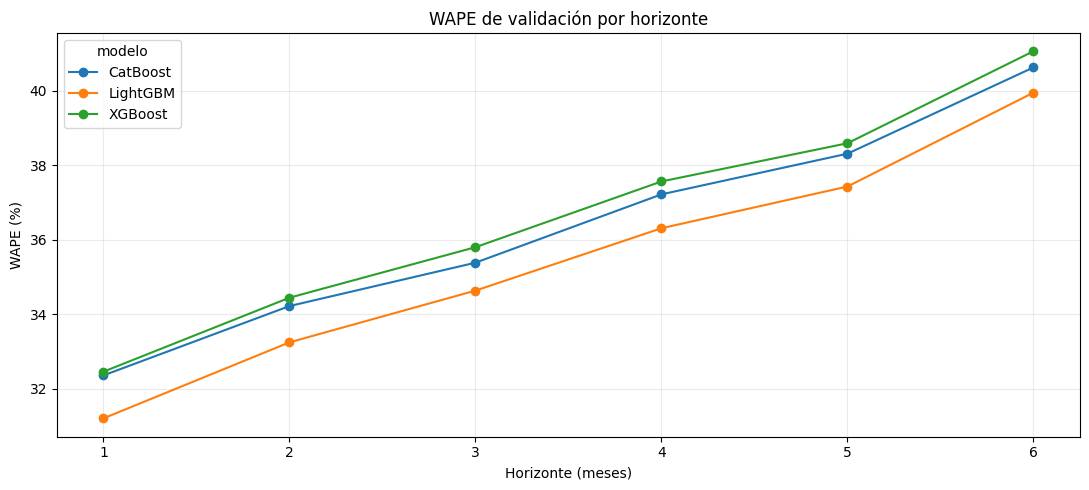

In [17]:
# ============================================================
# 17. MÉTRICAS POR HORIZONTE
# ============================================================

por_horizonte = (
    metricas_validacion
    .groupby(
        [
            "modelo",
            "horizonte",
        ],
        as_index=False,
    )
    .agg(
        WAPE_pct=(
            "modelo_WAPE_pct",
            "mean"
        ),
        MAE=(
            "modelo_MAE",
            "mean"
        ),
        RMSE=(
            "modelo_RMSE",
            "mean"
        ),
        sMAPE_pct=(
            "modelo_sMAPE_pct",
            "mean"
        ),
        R2=(
            "modelo_R2",
            "mean"
        ),
    )
)

display(
    por_horizonte.sort_values(
        [
            "horizonte",
            "WAPE_pct",
        ]
    )
)

tabla_plot = (
    por_horizonte
    .pivot(
        index="horizonte",
        columns="modelo",
        values="WAPE_pct",
    )
)

ax = tabla_plot.plot(
    marker="o",
    figsize=(11, 5),
)

ax.set_title(
    "WAPE de validación por horizonte"
)
ax.set_xlabel(
    "Horizonte (meses)"
)
ax.set_ylabel(
    "WAPE (%)"
)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# 18. TEST TEMPORAL INDEPENDIENTE
# ============================================================
# El test NO se utiliza para cambiar el ganador.
# ============================================================

partes_test = []

for nombre, modelo in modelos.items():
    partes_test.append(
        evaluar_modelo_corte(
            nombre=nombre,
            modelo=modelo,
            fecha_corte=CORTE_TEST,
            tipo="test",
        )
    )

metricas_test = pd.concat(
    partes_test,
    ignore_index=True,
)

metricas_test.to_csv(
    RUTA_METRICAS_TEST,
    index=False,
    encoding="utf-8-sig",
)

resumen_test = (
    metricas_test
    .groupby(
        "modelo",
        as_index=False,
    )
    .agg(
        WAPE_test_pct=(
            "modelo_WAPE_pct",
            "mean"
        ),
        MAE_test=(
            "modelo_MAE",
            "mean"
        ),
        RMSE_test=(
            "modelo_RMSE",
            "mean"
        ),
        sMAPE_test_pct=(
            "modelo_sMAPE_pct",
            "mean"
        ),
        R2_test=(
            "modelo_R2",
            "mean"
        ),
        baseline_WAPE_test_pct=(
            "baseline_WAPE_pct",
            "mean"
        ),
    )
    .sort_values("WAPE_test_pct")
)

display(
    resumen_test
)

print(
    "\nGanador elegido en validación:",
    MODELO_GANADOR
)

LightGBM   | corte=2025-07 | h=1 | WAPE=29.35% | baseline=32.72%
LightGBM   | corte=2025-07 | h=2 | WAPE=32.24% | baseline=33.26%
LightGBM   | corte=2025-07 | h=3 | WAPE=37.28% | baseline=36.11%
LightGBM   | corte=2025-07 | h=4 | WAPE=35.33% | baseline=32.61%
LightGBM   | corte=2025-07 | h=5 | WAPE=36.91% | baseline=33.63%
LightGBM   | corte=2025-07 | h=6 | WAPE=47.45% | baseline=43.74%
XGBoost    | corte=2025-07 | h=1 | WAPE=30.42% | baseline=32.72%
XGBoost    | corte=2025-07 | h=2 | WAPE=33.30% | baseline=33.26%
XGBoost    | corte=2025-07 | h=3 | WAPE=38.41% | baseline=36.11%
XGBoost    | corte=2025-07 | h=4 | WAPE=36.24% | baseline=32.61%
XGBoost    | corte=2025-07 | h=5 | WAPE=37.77% | baseline=33.63%
XGBoost    | corte=2025-07 | h=6 | WAPE=48.34% | baseline=43.74%
CatBoost   | corte=2025-07 | h=1 | WAPE=30.39% | baseline=32.72%
CatBoost   | corte=2025-07 | h=2 | WAPE=33.15% | baseline=33.26%
CatBoost   | corte=2025-07 | h=3 | WAPE=38.21% | baseline=36.11%
CatBoost   | corte=2025-0

,modelo,WAPE_test_pct,MAE_test,RMSE_test,sMAPE_test_pct,R2_test,baseline_WAPE_test_pct
1,LightGBM,36.424989,42.992165,1884.485472,49.556518,0.135183,35.345459
0,CatBoost,37.287310,44.016906,1900.159230,49.725899,0.120787,35.345459
2,XGBoost,37.414596,44.168715,1904.738293,49.434601,0.116586,35.345459



Ganador elegido en validación: LightGBM


In [19]:
# ============================================================
# 19. COMPARACIÓN FINAL
# ============================================================

comparacion = (
    resumen_validacion
    .merge(
        resumen_test,
        on="modelo",
        how="left",
    )
)

comparacion[
    "seleccionado"
] = (
    comparacion["modelo"]
    .eq(MODELO_GANADOR)
)

display(
    comparacion
)

comparacion.to_csv(
    RUTA_COMPARACION,
    index=False,
    encoding="utf-8-sig",
)

,modelo,WAPE_validacion_pct,MAE_validacion,RMSE_validacion,sMAPE_validacion_pct,R2_validacion,baseline_WAPE_pct,mejora_WAPE_vs_baseline_pct,WAPE_test_pct,MAE_test,RMSE_test,sMAPE_test_pct,R2_test,baseline_WAPE_test_pct,seleccionado
0,LightGBM,35.461218,43.541960,1882.554416,45.157941,0.138202,32.370679,-9.547342,36.424989,42.992165,1884.485472,49.556518,0.135183,35.345459,True
1,CatBoost,36.350959,44.634613,1897.289153,45.337638,0.124620,32.370679,-12.295943,37.287310,44.016906,1900.159230,49.725899,0.120787,35.345459,False
2,XGBoost,36.651033,45.002622,1902.324216,45.050865,0.119899,32.370679,-13.222935,37.414596,44.168715,1904.738293,49.434601,0.116586,35.345459,False


## Real vs. pronosticado en test

Esta sección usa el **modelo ganador seleccionado en validación** y el
corte de test `2025-07`.

Compara cliente a cliente los valores reales conocidos de:

- agosto de 2025;
- septiembre de 2025;
- octubre de 2025;
- noviembre de 2025;
- diciembre de 2025;
- enero de 2026;

contra lo que habría pronosticado el modelo sin conocer esos meses.

Esta es la comparación correcta entre **real y pronosticado**.

In [20]:
# ============================================================
# 20. REAL VS PRONOSTICADO - FUNCIÓN DETALLADA
# ============================================================

def generar_real_vs_pronosticado(
    modelo,
    nombre_modelo,
    fecha_corte,
):
    partes = []
    fecha_corte = periodo_mes(fecha_corte)

    for h in HORIZONTES:

        y_all, fecha_target = target_horizonte(
            fecha_corte,
            h,
        )

        validos12 = conteo_validos(
            fecha_corte,
            12,
        )

        candidatos = np.flatnonzero(
            np.isfinite(y_all)
            & (validos12 >= MIN_MESES_VALIDOS_12)
        )

        if len(candidatos) == 0:
            continue

        X_eval, _ = crear_features(
            fecha_corte,
            h,
            candidatos,
        )

        pronosticado = invertir_target(
            modelo.predict(X_eval)
        )

        baseline = baseline_hibrido(
            fecha_corte,
            h,
            candidatos,
        )

        real = y_all[candidatos]

        mask = (
            np.isfinite(real)
            & np.isfinite(pronosticado)
            & np.isfinite(baseline)
        )

        idx = candidatos[mask]
        real = real[mask].astype("float32")
        pronosticado = pronosticado[mask].astype("float32")
        baseline = baseline[mask].astype("float32")

        error = (
            pronosticado - real
        ).astype("float32")

        error_pct = np.full(
            len(real),
            np.nan,
            dtype="float32",
        )

        mask_real_pos = real > 0

        error_pct[mask_real_pos] = (
            error[mask_real_pos]
            / real[mask_real_pos]
            * 100
        )

        partes.append(
            pd.DataFrame(
                {
                    "NIU": nius[idx],
                    "modelo": nombre_modelo,
                    "fecha_corte": fecha_corte,
                    "horizonte": h,
                    "fecha_target": fecha_target,
                    "real_kwh": real,
                    "pronosticado_kwh": pronosticado,
                    "baseline_kwh": baseline,
                    "error_kwh": error,
                    "error_abs_kwh": np.abs(error),
                    "error_pct": error_pct,
                    "meses_validos_12m": validos12[idx].astype("int8"),
                }
            )
        )

        print(
            f"h={h} | target={fecha_target:%Y-%m} | "
            f"comparables={mask.sum():,}"
        )

        del X_eval
        del pronosticado
        gc.collect()

    if not partes:
        raise ValueError(
            "No se pudieron generar comparaciones real vs pronosticado."
        )

    return pd.concat(
        partes,
        ignore_index=True,
    )

In [21]:
# ============================================================
# 21. GENERAR Y GUARDAR REAL VS PRONOSTICADO
# ============================================================

modelo_ganador_test = modelos[
    MODELO_GANADOR
]

real_vs_pred = generar_real_vs_pronosticado(
    modelo=modelo_ganador_test,
    nombre_modelo=MODELO_GANADOR,
    fecha_corte=CORTE_TEST,
)

print("\nREAL VS PRONOSTICADO")
print("-" * 60)
print(f"Filas : {len(real_vs_pred):,}")
print(f"NIU   : {real_vs_pred['NIU'].nunique():,}")

display(
    real_vs_pred.head(20)
)

real_vs_pred.to_parquet(
    RUTA_REAL_VS_PRED_TEST,
    index=False,
    engine="pyarrow",
)

print(
    "\nGuardado:",
    RUTA_REAL_VS_PRED_TEST
)

h=1 | target=2025-08 | comparables=564,267
h=2 | target=2025-09 | comparables=564,673
h=3 | target=2025-10 | comparables=564,775
h=4 | target=2025-11 | comparables=564,613
h=5 | target=2025-12 | comparables=564,622
h=6 | target=2026-01 | comparables=563,003

REAL VS PRONOSTICADO
------------------------------------------------------------
Filas : 3,385,953
NIU   : 564,940


,NIU,modelo,fecha_corte,horizonte,fecha_target,real_kwh,pronosticado_kwh,baseline_kwh,error_kwh,error_abs_kwh,error_pct,meses_validos_12m
0,1000006589,LightGBM,2025-07-01,1,2025-08-01,32.000000,35.760193,93.000000,3.760193,3.760193,11.750603,12
1,1000007366,LightGBM,2025-07-01,1,2025-08-01,82.000000,68.474014,86.000000,-13.525986,13.525986,-16.495104,12
2,1000008143,LightGBM,2025-07-01,1,2025-08-01,46.000000,42.137653,63.000000,-3.862347,3.862347,-8.396406,12
3,100000949,LightGBM,2025-07-01,1,2025-08-01,41.689655,40.981480,68.065216,-0.708176,0.708176,-1.698684,12
4,1000009920,LightGBM,2025-07-01,1,2025-08-01,75.000000,71.674744,74.000000,-3.325256,3.325256,-4.433675,12
5,1000010766,LightGBM,2025-07-01,1,2025-08-01,103.000000,98.727959,104.000000,-4.272041,4.272041,-4.147613,12
6,100001726,LightGBM,2025-07-01,1,2025-08-01,0.000000,0.151523,0.000000,0.151523,0.151523,NaN,12
7,100002503,LightGBM,2025-07-01,1,2025-08-01,12.130435,13.482856,10.782609,1.352421,1.352421,11.148989,12
8,100003390,LightGBM,2025-07-01,1,2025-08-01,25.655172,28.487574,19.880434,2.832401,2.832401,11.040274,12
9,100004177,LightGBM,2025-07-01,1,2025-08-01,47.847828,38.408039,9.434783,-9.439789,9.439789,-19.728773,12



Guardado: C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\modelacion_consumo\real_vs_pronosticado_test.parquet


In [22]:
# ============================================================
# 22. RESUMEN REAL VS PRONOSTICADO POR HORIZONTE
# ============================================================

def calcular_wape(real, pred):
    real = np.asarray(real, dtype="float64")
    pred = np.asarray(pred, dtype="float64")

    denom = np.abs(real).sum()

    if denom == 0:
        return np.nan

    return (
        np.abs(real - pred).sum()
        / denom
        * 100
    )


resumen_real_vs_pred = (
    real_vs_pred
    .groupby(
        [
            "horizonte",
            "fecha_target",
        ],
        as_index=False,
    )
    .apply(
        lambda g: pd.Series(
            {
                "n": len(g),
                "real_total_kwh":
                    g["real_kwh"].sum(),
                "pronosticado_total_kwh":
                    g["pronosticado_kwh"].sum(),
                "baseline_total_kwh":
                    g["baseline_kwh"].sum(),
                "real_promedio_kwh":
                    g["real_kwh"].mean(),
                "pronosticado_promedio_kwh":
                    g["pronosticado_kwh"].mean(),
                "MAE_modelo":
                    g["error_abs_kwh"].mean(),
                "WAPE_modelo_pct":
                    calcular_wape(
                        g["real_kwh"],
                        g["pronosticado_kwh"],
                    ),
                "WAPE_baseline_pct":
                    calcular_wape(
                        g["real_kwh"],
                        g["baseline_kwh"],
                    ),
                "sesgo_total_kwh":
                    (
                        g["pronosticado_kwh"].sum()
                        - g["real_kwh"].sum()
                    ),
            }
        )
    )
    .reset_index(drop=True)
)

resumen_real_vs_pred[
    "sesgo_total_pct"
] = np.where(
    resumen_real_vs_pred["real_total_kwh"] != 0,
    (
        resumen_real_vs_pred["sesgo_total_kwh"]
        / resumen_real_vs_pred["real_total_kwh"]
        * 100
    ),
    np.nan,
)

display(
    resumen_real_vs_pred
)

resumen_real_vs_pred.to_csv(
    RUTA_REAL_VS_PRED_RESUMEN,
    index=False,
    encoding="utf-8-sig",
)

,horizonte,fecha_target,n,real_total_kwh,pronosticado_total_kwh,baseline_total_kwh,real_promedio_kwh,pronosticado_promedio_kwh,MAE_modelo,WAPE_modelo_pct,WAPE_baseline_pct,sesgo_total_kwh,sesgo_total_pct
0,1,2025-08-01,564267.0,69274544.0,57971256.0,71819280.0,122.769089,102.737282,36.034878,29.351754,32.719895,-11303288.0,-16.316654
1,2,2025-09-01,564673.0,70165680.0,56776196.0,68508344.0,124.258957,100.547035,40.056202,32.236070,33.261239,-13389484.0,-19.082668
2,3,2025-10-01,564775.0,65071328.0,56325624.0,69567984.0,115.216377,99.731087,42.950420,37.278051,36.112349,-8745704.0,-13.440181
3,4,2025-11-01,564613.0,68301648.0,55580232.0,68542272.0,120.970734,98.439522,42.734173,35.326046,32.611036,-12721416.0,-18.625343
4,5,2025-12-01,564622.0,67876496.0,55193416.0,68651480.0,120.215820,97.752861,44.374638,36.912472,33.625270,-12683080.0,-18.685526
5,6,2026-01-01,563003.0,61470608.0,53750900.0,70681472.0,109.183449,95.471779,51.802681,47.445544,43.742968,-7719708.0,-12.558373


In [23]:
# ============================================================
# 23. DESEMPEÑO REAL VS PRONOSTICADO POR NIVEL DE CONSUMO
# ============================================================

bins_consumo = [
    -np.inf,
    0,
    10,
    50,
    100,
    500,
    1_000,
    5_000,
    np.inf,
]

labels_consumo = [
    "0 kWh",
    ">0-10",
    ">10-50",
    ">50-100",
    ">100-500",
    ">500-1.000",
    ">1.000-5.000",
    ">5.000",
]

real_vs_pred[
    "segmento_consumo_real"
] = pd.cut(
    real_vs_pred["real_kwh"],
    bins=bins_consumo,
    labels=labels_consumo,
    include_lowest=True,
)

segmentos_real_vs_pred = (
    real_vs_pred
    .groupby(
        [
            "horizonte",
            "segmento_consumo_real",
        ],
        observed=True,
        as_index=False,
    )
    .apply(
        lambda g: pd.Series(
            {
                "n": len(g),
                "real_total_kwh":
                    g["real_kwh"].sum(),
                "pronosticado_total_kwh":
                    g["pronosticado_kwh"].sum(),
                "MAE_kwh":
                    g["error_abs_kwh"].mean(),
                "WAPE_modelo_pct":
                    calcular_wape(
                        g["real_kwh"],
                        g["pronosticado_kwh"],
                    ),
            }
        )
    )
    .reset_index(drop=True)
)

display(
    segmentos_real_vs_pred
)

segmentos_real_vs_pred.to_csv(
    RUTA_REAL_VS_PRED_SEGMENTOS,
    index=False,
    encoding="utf-8-sig",
)

,horizonte,segmento_consumo_real,n,real_total_kwh,pronosticado_total_kwh,MAE_kwh,WAPE_modelo_pct
0,1,0 kWh,52928.0,0.000000e+00,2.639086e+05,4.986180,NaN
1,1,>0-10,62128.0,2.405263e+05,3.636417e+05,2.891829,74.696013
2,1,>10-50,146327.0,4.584072e+06,4.674620e+06,6.265451,19.999789
3,1,>50-100,155389.0,1.133897e+07,1.086444e+07,10.292471,14.104779
4,1,>100-500,135752.0,2.335905e+07,2.145426e+07,24.764833,14.392178
5,1,>500-1.000,6697.0,4.611558e+06,4.170213e+06,117.414421,17.051164
6,1,>1.000-5.000,4203.0,8.315481e+06,7.976134e+06,510.315918,25.793550
7,1,>5.000,843.0,1.682488e+07,8.204032e+06,13144.153320,65.857937
8,2,0 kWh,53046.0,0.000000e+00,3.751495e+05,7.072154,NaN
9,2,>0-10,62457.0,2.399809e+05,4.332273e+05,3.992638,103.911685


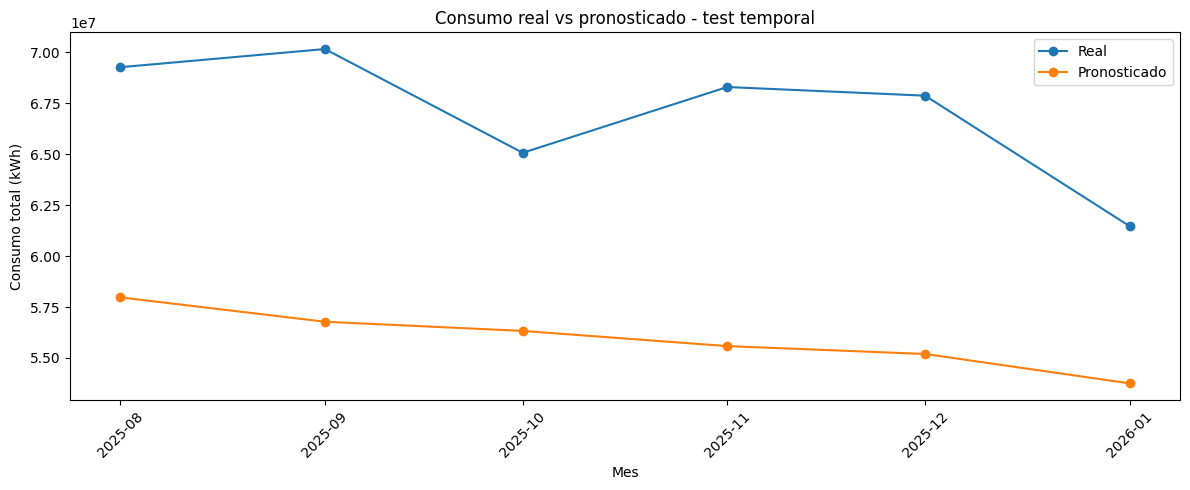

In [24]:
# ============================================================
# 24. GRÁFICA REAL VS PRONOSTICADO
# ============================================================

grafica = (
    resumen_real_vs_pred
    .sort_values("fecha_target")
)

plt.figure(
    figsize=(12, 5)
)

plt.plot(
    grafica["fecha_target"],
    grafica["real_total_kwh"],
    marker="o",
    label="Real",
)

plt.plot(
    grafica["fecha_target"],
    grafica["pronosticado_total_kwh"],
    marker="o",
    label="Pronosticado",
)

plt.title(
    "Consumo real vs pronosticado - test temporal"
)

plt.xlabel("Mes")
plt.ylabel("Consumo total (kWh)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Reentrenamiento del modelo ganador

Después de elegir el algoritmo con validación y comprobarlo en test, se vuelve a entrenar **solo el ganador** utilizando targets conocidos hasta el último mes disponible.

Así se aprovecha la información más reciente antes de generar el pronóstico real.

In [25]:
# ============================================================
# 25. TRAIN FINAL CON TODO LO CONOCIDO
# ============================================================

FECHA_CORTE_FINAL = periodo_mes(
    periodo_max
)

print(
    "Fecha de corte final:",
    FECHA_CORTE_FINAL.strftime("%Y-%m")
)

print("\nPronósticos:")

for h in HORIZONTES:
    print(
        f"t+{h}: "
        f"{sumar_meses(FECHA_CORTE_FINAL, h):%Y-%m}"
    )

inicio = time.time()

X_train_final, y_train_final, auditoria_final = (
    construir_dataset_train(
        max_target_train=
            FECHA_CORTE_FINAL,
        muestra_por_grupo=
            MUESTRA_POR_ORIGEN_H,
        seed=SEED + 100,
    )
)

y_train_final_log = transformar_target(
    y_train_final
)

print(
    "\nX final:",
    X_train_final.shape
)
print(
    "y final:",
    y_train_final.shape
)
print(
    "Tiempo construcción:",
    f"{(time.time() - inicio) / 60:.2f} min"
)

Fecha de corte final: 2026-01

Pronósticos:
t+1: 2026-02
t+2: 2026-03
t+3: 2026-04
t+4: 2026-05
t+5: 2026-06
t+6: 2026-07
[1/201] origen=2023-01 h=1 target=2023-02 muestra=50,000
[10/201] origen=2023-02 h=4 target=2023-06 muestra=50,000
[20/201] origen=2023-04 h=2 target=2023-06 muestra=50,000
[30/201] origen=2023-05 h=6 target=2023-11 muestra=50,000
[40/201] origen=2023-07 h=4 target=2023-11 muestra=50,000
[50/201] origen=2023-09 h=2 target=2023-11 muestra=50,000
[60/201] origen=2023-10 h=6 target=2024-04 muestra=50,000
[70/201] origen=2023-12 h=4 target=2024-04 muestra=50,000
[80/201] origen=2024-02 h=2 target=2024-04 muestra=50,000
[90/201] origen=2024-03 h=6 target=2024-09 muestra=50,000
[100/201] origen=2024-05 h=4 target=2024-09 muestra=50,000
[110/201] origen=2024-07 h=2 target=2024-09 muestra=50,000
[120/201] origen=2024-08 h=6 target=2025-02 muestra=50,000
[130/201] origen=2024-10 h=4 target=2025-02 muestra=50,000
[140/201] origen=2024-12 h=2 target=2025-02 muestra=50,000
[150

In [26]:
# ============================================================
# 26. ENTRENAR Y GUARDAR MODELO GANADOR
# ============================================================

modelo_final = nuevo_modelo(
    MODELO_GANADOR
)

inicio = time.time()

modelo_final.fit(
    X_train_final,
    y_train_final_log,
)

print(
    f"{MODELO_GANADOR} final entrenado en "
    f"{(time.time() - inicio) / 60:.2f} min"
)

joblib.dump(
    {
        "modelo": modelo_final,
        "modelo_nombre": MODELO_GANADOR,
        "features": FEATURES,
        "fecha_corte": FECHA_CORTE_FINAL,
        "horizontes": HORIZONTES,
        "target_transform": "log1p",
        "min_meses_validos_12":
            MIN_MESES_VALIDOS_12,
    },
    RUTA_MODELO,
)

print(
    "Modelo guardado:",
    RUTA_MODELO
)

LightGBM final entrenado en 2.20 min
Modelo guardado: C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\modelacion_consumo\modelo_consumo_ganador.joblib


In [27]:
# ============================================================
# 27. CLIENTES ELEGIBLES PARA PRONÓSTICO FINAL
# ============================================================

actual_final = valores_mes(
    FECHA_CORTE_FINAL
)

validos12_final = conteo_validos(
    FECHA_CORTE_FINAL,
    12,
)

indices_final = np.flatnonzero(
    np.isfinite(actual_final)
    & (
        validos12_final
        >= MIN_MESES_VALIDOS_12
    )
)

print(
    f"NIU totales              : {len(nius):,}"
)
print(
    f"NIU presentes en corte   : "
    f"{np.sum(np.isfinite(actual_final)):,}"
)
print(
    f"NIU elegibles pronóstico : {len(indices_final):,}"
)

NIU totales              : 592,159
NIU presentes en corte   : 577,360
NIU elegibles pronóstico : 569,286


In [28]:
# ============================================================
# 28. PREDICCIONES t+1 A t+6
# ============================================================

predicciones = pd.DataFrame(
    {
        "NIU":
            nius[
                indices_final
            ],
        "fecha_corte":
            FECHA_CORTE_FINAL,
        "consumo_actual_corte":
            actual_final[
                indices_final
            ],
        "meses_validos_12m":
            validos12_final[
                indices_final
            ].astype("int8"),
        "modelo":
            MODELO_GANADOR,
    }
)

for h in HORIZONTES:
    fecha_pred = sumar_meses(
        FECHA_CORTE_FINAL,
        h,
    )

    print(
        f"Prediciendo t+{h}: "
        f"{fecha_pred:%Y-%m}"
    )

    X_pred, _ = crear_features(
        FECHA_CORTE_FINAL,
        h,
        indices_final,
    )

    pred = invertir_target(
        modelo_final.predict(
            X_pred
        )
    )

    predicciones[
        f"fecha_pred_{h}m"
    ] = fecha_pred

    predicciones[
        f"pred_{h}m_kwh"
    ] = pred

    del X_pred
    del pred
    gc.collect()

display(
    predicciones.head(10)
)

Prediciendo t+1: 2026-02
Prediciendo t+2: 2026-03
Prediciendo t+3: 2026-04
Prediciendo t+4: 2026-05
Prediciendo t+5: 2026-06
Prediciendo t+6: 2026-07


,NIU,fecha_corte,consumo_actual_corte,meses_validos_12m,modelo,fecha_pred_1m,pred_1m_kwh,fecha_pred_2m,pred_2m_kwh,fecha_pred_3m,pred_3m_kwh,fecha_pred_4m,pred_4m_kwh,fecha_pred_5m,pred_5m_kwh,fecha_pred_6m,pred_6m_kwh
0,1000006589,2026-01-01,131.000000,12,LightGBM,2026-02-01,95.182434,2026-03-01,83.517464,2026-04-01,87.575752,2026-05-01,76.076431,2026-06-01,75.698151,2026-07-01,72.004227
1,1000007366,2026-01-01,84.000000,12,LightGBM,2026-02-01,77.142639,2026-03-01,72.497261,2026-04-01,77.180199,2026-05-01,73.896217,2026-06-01,74.087967,2026-07-01,71.343132
2,1000008143,2026-01-01,57.000000,12,LightGBM,2026-02-01,50.664406,2026-03-01,49.416615,2026-04-01,49.959347,2026-05-01,45.519680,2026-06-01,46.489349,2026-07-01,46.162712
3,100000949,2026-01-01,22.855556,12,LightGBM,2026-02-01,20.807510,2026-03-01,21.896648,2026-04-01,27.479074,2026-05-01,26.381128,2026-06-01,26.277203,2026-07-01,26.118113
4,1000009920,2026-01-01,72.000000,12,LightGBM,2026-02-01,66.674759,2026-03-01,64.609238,2026-04-01,69.094704,2026-05-01,64.893082,2026-06-01,64.893929,2026-07-01,63.498688
5,1000010766,2026-01-01,98.000000,12,LightGBM,2026-02-01,90.231354,2026-03-01,85.089066,2026-04-01,92.625046,2026-05-01,88.370895,2026-06-01,87.729950,2026-07-01,85.134781
6,100001726,2026-01-01,0.000000,12,LightGBM,2026-02-01,0.044932,2026-03-01,0.074385,2026-04-01,0.144063,2026-05-01,0.184009,2026-06-01,0.208978,2026-07-01,0.244034
7,100002503,2026-01-01,11.170213,12,LightGBM,2026-02-01,11.265166,2026-03-01,12.078212,2026-04-01,12.789025,2026-05-01,12.393734,2026-06-01,12.424204,2026-07-01,12.393781
8,100003390,2026-01-01,17.000000,12,LightGBM,2026-02-01,18.523540,2026-03-01,18.642420,2026-04-01,20.412529,2026-05-01,19.505550,2026-06-01,19.545887,2026-07-01,19.509880
9,100004177,2026-01-01,28.148935,12,LightGBM,2026-02-01,25.230732,2026-03-01,26.855200,2026-04-01,30.903898,2026-05-01,29.682436,2026-06-01,29.608788,2026-07-01,29.396276


In [29]:
# ============================================================
# 29. RESUMEN 3 Y 6 MESES POR CLIENTE
# ============================================================

predicciones[
    "promedio_pred_3m_kwh"
] = predicciones[
    [
        "pred_1m_kwh",
        "pred_2m_kwh",
        "pred_3m_kwh",
    ]
].mean(axis=1)

predicciones[
    "promedio_pred_6m_kwh"
] = predicciones[
    [
        "pred_1m_kwh",
        "pred_2m_kwh",
        "pred_3m_kwh",
        "pred_4m_kwh",
        "pred_5m_kwh",
        "pred_6m_kwh",
    ]
].mean(axis=1)

actual = predicciones[
    "consumo_actual_corte"
]

predicciones[
    "variacion_pred_3m_pct"
] = np.where(
    actual > 0,
    (
        predicciones["pred_3m_kwh"]
        - actual
    )
    / actual
    * 100,
    np.nan,
)

predicciones[
    "variacion_pred_6m_pct"
] = np.where(
    actual > 0,
    (
        predicciones["pred_6m_kwh"]
        - actual
    )
    / actual
    * 100,
    np.nan,
)


def tendencia(variacion):
    return np.select(
        [
            variacion <= -10,
            variacion >= 10,
        ],
        [
            "decreciente",
            "creciente",
        ],
        default="estable",
    )


predicciones[
    "tendencia_3m"
] = tendencia(
    predicciones[
        "variacion_pred_3m_pct"
    ]
)

predicciones[
    "tendencia_6m"
] = tendencia(
    predicciones[
        "variacion_pred_6m_pct"
    ]
)

display(
    predicciones[
        [
            "NIU",
            "consumo_actual_corte",
            "pred_1m_kwh",
            "pred_2m_kwh",
            "pred_3m_kwh",
            "pred_6m_kwh",
            "promedio_pred_3m_kwh",
            "promedio_pred_6m_kwh",
            "tendencia_3m",
            "tendencia_6m",
        ]
    ].head(20)
)

,NIU,consumo_actual_corte,pred_1m_kwh,pred_2m_kwh,pred_3m_kwh,pred_6m_kwh,promedio_pred_3m_kwh,promedio_pred_6m_kwh,tendencia_3m,tendencia_6m
0,1000006589,131.000000,95.182434,83.517464,87.575752,72.004227,88.758545,81.675743,decreciente,decreciente
1,1000007366,84.000000,77.142639,72.497261,77.180199,71.343132,75.606697,74.357903,estable,decreciente
2,1000008143,57.000000,50.664406,49.416615,49.959347,46.162712,50.013458,48.035355,decreciente,decreciente
3,100000949,22.855556,20.807510,21.896648,27.479074,26.118113,23.394411,24.826614,creciente,creciente
4,1000009920,72.000000,66.674759,64.609238,69.094704,63.498688,66.792900,65.610733,estable,decreciente
5,1000010766,98.000000,90.231354,85.089066,92.625046,85.134781,89.315155,88.196846,estable,decreciente
6,100001726,0.000000,0.044932,0.074385,0.144063,0.244034,0.087794,0.150067,estable,estable
7,100002503,11.170213,11.265166,12.078212,12.789025,12.393781,12.044135,12.224021,creciente,creciente
8,100003390,17.000000,18.523540,18.642420,20.412529,19.509880,19.192831,19.356634,creciente,creciente
9,100004177,28.148935,25.230732,26.855200,30.903898,29.396276,27.663277,28.612886,estable,estable


In [30]:
# ============================================================
# 30. VALIDACIÓN FINAL DE PRONÓSTICOS
# ============================================================

cols_pred = [
    f"pred_{h}m_kwh"
    for h in HORIZONTES
]

nulos = int(
    predicciones[
        cols_pred
    ]
    .isna()
    .sum()
    .sum()
)

negativos = int(
    (
        predicciones[
            cols_pred
        ] < 0
    )
    .sum()
    .sum()
)

print("VALIDACIÓN PRONÓSTICOS")
print("-" * 60)
print(f"Clientes              : {len(predicciones):,}")
print(f"Predicciones nulas    : {nulos:,}")
print(f"Predicciones negativas: {negativos:,}")

if negativos != 0:
    raise ValueError(
        "Se generaron predicciones negativas."
    )

display(
    predicciones[
        cols_pred
    ]
    .describe(
        percentiles=[
            .01, .05, .25, .50,
            .75, .95, .99
        ]
    )
    .T
)

VALIDACIÓN PRONÓSTICOS
------------------------------------------------------------
Clientes              : 569,286
Predicciones nulas    : 0
Predicciones negativas: 0


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
pred_1m_kwh,569286.0,89.655983,410.959686,0.0,0.044932,0.099673,7.868952,39.472132,87.882231,228.468342,791.191437,20575.265625
pred_2m_kwh,569286.0,85.090218,387.276642,0.0,0.074385,0.126965,9.119636,39.332201,82.316051,212.973476,745.373340,19803.169922
pred_3m_kwh,569286.0,89.137611,389.776001,0.0,0.144063,0.302159,11.197321,41.935055,88.304924,222.591824,765.775208,20137.304688
pred_4m_kwh,569286.0,84.007042,369.062225,0.0,0.184009,0.330388,10.987596,39.873978,82.978928,209.543617,712.661438,18678.496094
pred_5m_kwh,569286.0,84.646721,369.226532,0.0,0.208978,0.367484,11.466765,40.767664,83.182388,210.715916,716.126566,18840.386719
pred_6m_kwh,569286.0,82.480537,357.943237,0.0,0.244034,0.408379,11.524604,39.640083,80.777504,205.297676,697.690091,17879.943359


In [31]:
# ============================================================
# 31. GUARDAR SALIDAS 3 Y 6 MESES
# ============================================================

base_cols = [
    "NIU",
    "fecha_corte",
    "consumo_actual_corte",
    "meses_validos_12m",
    "modelo",
]

cols_3m = (
    base_cols
    + [
        "fecha_pred_1m",
        "pred_1m_kwh",
        "fecha_pred_2m",
        "pred_2m_kwh",
        "fecha_pred_3m",
        "pred_3m_kwh",
        "promedio_pred_3m_kwh",
        "variacion_pred_3m_pct",
        "tendencia_3m",
    ]
)

cols_6m = (
    base_cols
    + [
        "fecha_pred_1m",
        "pred_1m_kwh",
        "fecha_pred_2m",
        "pred_2m_kwh",
        "fecha_pred_3m",
        "pred_3m_kwh",
        "fecha_pred_4m",
        "pred_4m_kwh",
        "fecha_pred_5m",
        "pred_5m_kwh",
        "fecha_pred_6m",
        "pred_6m_kwh",
        "promedio_pred_3m_kwh",
        "promedio_pred_6m_kwh",
        "variacion_pred_3m_pct",
        "variacion_pred_6m_pct",
        "tendencia_3m",
        "tendencia_6m",
    ]
)

pred_3m = predicciones[
    cols_3m
].copy()

pred_6m = predicciones[
    cols_6m
].copy()

pred_3m.to_parquet(
    RUTA_PRED_3M,
    index=False,
    engine="pyarrow",
)

pred_6m.to_parquet(
    RUTA_PRED_6M,
    index=False,
    engine="pyarrow",
)

print("MODELACIÓN TERMINADA")
print("=" * 70)
print("\nModelo ganador:")
print(MODELO_GANADOR)

print("\nMétricas:")
print(" •", RUTA_METRICAS_VALIDACION)
print(" •", RUTA_METRICAS_TEST)
print(" •", RUTA_COMPARACION)

print("\nModelo:")
print(" •", RUTA_MODELO)

print("\nPredicciones:")
print(" • 3 meses:", RUTA_PRED_3M)
print(" • 6 meses:", RUTA_PRED_6M)

print("\nReal vs pronosticado:")
print(" •", RUTA_REAL_VS_PRED_TEST)
print(" •", RUTA_REAL_VS_PRED_RESUMEN)
print(" •", RUTA_REAL_VS_PRED_SEGMENTOS)


MODELACIÓN TERMINADA

Modelo ganador:
LightGBM

Métricas:
 • C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\modelacion_consumo\metricas_validacion_modelos.csv
 • C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\modelacion_consumo\metricas_test_modelos.csv
 • C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\modelacion_consumo\comparacion_modelos.csv

Modelo:
 • C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\modelacion_consumo\modelo_consumo_ganador.joblib

Predicciones:
 • 3 meses: C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\modelacion_consumo\predicciones_consumo_3_meses.parquet
 • 6 meses: C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\modelacion_consumo\predicciones_consumo_6_meses.parquet

Real vs pronosticado:
 • C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\modelacion_consumo\real_vs_pronosticado_test.parquet
 • C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\modelacion_consumo\real_vs_pronosticado_test_resumen

# Cómo interpretar la comparación

La selección automática utiliza **WAPE promedio de validación** como criterio principal y MAE como desempate.

Conviene revisar también:

- **MAE:** error absoluto medio en kWh.
- **RMSE:** penaliza más los errores grandes.
- **WAPE:** error agregado relativo al volumen total; es la métrica principal.
- **sMAPE:** útil para comparar clientes con consumos pequeños.
- **R²:** capacidad explicativa, pero no debe utilizarse sola.
- **Baseline:** el modelo ganador debería superar al baseline híbrido en el test.

## Archivos finales

- `metricas_validacion_modelos.csv`
- `metricas_test_modelos.csv`
- `comparacion_modelos.csv`
- `modelo_consumo_ganador.joblib`
- `predicciones_consumo_3_meses.parquet`
- `predicciones_consumo_6_meses.parquet`

La salida de 6 meses incluye también los primeros 3 meses, por lo que permite evaluar tanto el horizonte corto como el semestral.